# Day 25 — Encoding Categorical Data and Ethics in AI/ML
### Module 6: Model Evaluation and Improvement

**Dataset:** Forest Cover Type (UCI Machine Learning Repository, via `sklearn.datasets.fetch_covtype`)

### Learning Objectives
By the end of this session, you will be able to:
- Explain why categorical data must be encoded before most ML algorithms can use it
- Describe six encoding techniques: Label Encoding, One-Hot Encoding, Ordinal Encoding, Binary Encoding, Frequency Encoding, and Target Encoding
- Implement Label Encoding and One-Hot Encoding with code
- Choose the right encoding technique for a given situation
- Explain the core pillars of AI/ML ethics: fairness, bias, privacy, transparency, accountability, and responsible AI
- Connect encoding choices themselves to real ethical considerations

### Session Roadmap
1. Dataset Loading and Basic EDA
2. Why Categorical Encoding Matters
3. Encoding Techniques — Theory
4. Label Encoding — Demonstration
5. One-Hot Encoding — Demonstration
6. Ordinal Encoding — Demonstration
7. Binary Encoding — Concept and Simple Demonstration
8. Frequency Encoding — Demonstration
9. Target Encoding — Demonstration (and its risks)
10. Choosing the Right Encoding — Decision Guide
11. AI/ML Ethics: Fairness, Bias, Privacy, Transparency, Accountability, Responsible AI
12. Practice and Interview Questions
13. Summary


## 1. Dataset Loading

The **Forest Cover Type** dataset contains cartographic measurements (elevation, slope, distances to features, soil type, wilderness area) for 30x30 meter cells of forest land, with the goal of predicting the type of tree cover.

**A note on this dataset's structure:** in `sklearn`'s version, the original categorical columns `Wilderness_Area` (4 categories) and `Soil_Type` (40 categories) are already provided as one-hot encoded binary columns. For this session, we **reconstruct** them back into single categorical columns — this lets us treat the data as if it arrived in its original, raw categorical form, which is exactly the situation you'll face with most real-world datasets.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

pd.set_option('display.max_columns', None)
np.random.seed(42)

In [2]:
covtype = fetch_covtype(as_frame=True)
df_full = covtype.frame

print("Full dataset shape:", df_full.shape)
df_full.head()


Full dataset shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type_0,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


In [3]:
# The full dataset has 581,012 rows -- for a smooth, fast classroom session, we work with a sample.
# (In a real project, you would use the full dataset; sampling here is purely for speed during live coding.)
df = df_full.sample(20000, random_state=42).reset_index(drop=True)
print("Working sample shape:", df.shape)


Working sample shape: (20000, 55)


## 2. Basic EDA


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Elevation                           20000 non-null  float64
 1   Aspect                              20000 non-null  float64
 2   Slope                               20000 non-null  float64
 3   Horizontal_Distance_To_Hydrology    20000 non-null  float64
 4   Vertical_Distance_To_Hydrology      20000 non-null  float64
 5   Horizontal_Distance_To_Roadways     20000 non-null  float64
 6   Hillshade_9am                       20000 non-null  float64
 7   Hillshade_Noon                      20000 non-null  float64
 8   Hillshade_3pm                       20000 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  20000 non-null  float64
 10  Wilderness_Area_0                   20000 non-null  float64
 11  Wilderness_Area_1                   20000

In [24]:
df['Cover_Type'].value_counts()

Cover_Type
2    9725
1    7365
3    1207
7     674
6     627
5     317
4      85
Name: count, dtype: int64

In [25]:
df['Soil_Type_39'].value_counts()

Soil_Type_39
0.0    19699
1.0      301
Name: count, dtype: int64

In [5]:
df.isnull().sum().sum()   # confirm no missing values


0

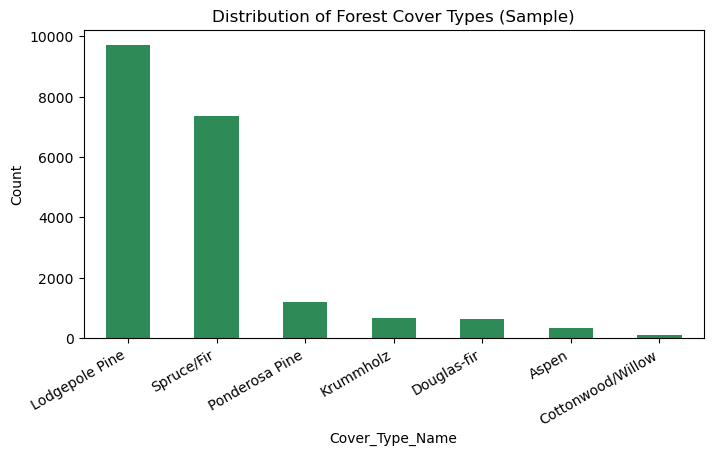

In [6]:
# Map the numeric Cover_Type target to readable class names, for clearer charts and discussion
cover_type_names = {
    1: 'Spruce/Fir', 2: 'Lodgepole Pine', 3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
    5: 'Aspen', 6: 'Douglas-fir', 7: 'Krummholz'
}
df['Cover_Type_Name'] = df['Cover_Type'].map(cover_type_names)

plt.figure(figsize=(8, 4))
df['Cover_Type_Name'].value_counts().plot(kind='bar', color='seagreen')
plt.title('Distribution of Forest Cover Types (Sample)')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.show()


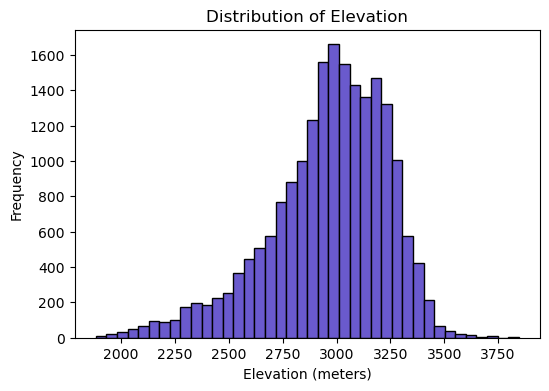

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(df['Elevation'], bins=40, color='slateblue', edgecolor='black')
plt.title('Distribution of Elevation')
plt.xlabel('Elevation (meters)')
plt.ylabel('Frequency')
plt.show()


## 3. Reconstructing Categorical Columns

`Wilderness_Area` was originally one-hot encoded into 4 binary columns (`Wilderness_Area1`...`Wilderness_Area4`), and `Soil_Type` into 40 binary columns. We collapse each group back into a single categorical column using `idxmax()`, which finds which binary column is "1" for each row.


In [8]:
wilderness_cols = [c for c in df.columns if c.startswith('Wilderness_Area')]
soil_cols = [c for c in df.columns if c.startswith('Soil_Type')]

print("Number of Wilderness_Area columns:", len(wilderness_cols))
print("Number of Soil_Type columns:", len(soil_cols))


Number of Wilderness_Area columns: 4
Number of Soil_Type columns: 40


In [9]:
df['Wilderness_Area'] = df[wilderness_cols].idxmax(axis=1).str.replace('Wilderness_Area', 'Area_')
df['Soil_Type'] = df[soil_cols].idxmax(axis=1).str.replace('Soil_Type', 'Soil_')

df[['Wilderness_Area', 'Soil_Type']].head()


,Wilderness_Area,Soil_Type
0,Area__0,Soil__37
1,Area__2,Soil__27
2,Area__2,Soil__10
3,Area__0,Soil__11
4,Area__0,Soil__17


In [10]:
print("Unique Wilderness_Area categories:", df['Wilderness_Area'].nunique())
print("Unique Soil_Type categories:", df['Soil_Type'].nunique())

df['Wilderness_Area'].value_counts()


Unique Wilderness_Area categories: 4
Unique Soil_Type categories: 39


Wilderness_Area
Area__2    8915
Area__0    8904
Area__3    1215
Area__1     966
Name: count, dtype: int64

**Notice:** `Wilderness_Area` has only 4 categories (low cardinality — a good candidate for one-hot encoding), while `Soil_Type` has up to 40 categories in the full dataset (high cardinality — one-hot encoding here would create up to 40 extra columns, motivating some of the alternative encodings we'll cover today).


In [27]:
df['Elevation'].describe()

count    20000.00000
mean      2961.23935
std        276.77791
min       1883.00000
25%       2812.00000
50%       2997.50000
75%       3164.00000
max       3845.00000
Name: Elevation, dtype: float64

## 4. Creating an Ordinal Feature — Elevation Category

For demonstrating **ordinal** encoding specifically, we need a categorical feature where the categories have a genuine, meaningful order. We bin the continuous `Elevation` column into Low/Medium/High — these categories are NOT just labels, they have a clear rank.


In [11]:
df['Elevation_Category'] = pd.cut(
    df['Elevation'],
    bins=[0, 2500, 3200, df['Elevation'].max()],
    labels=['Low', 'Medium', 'High']
)

df['Elevation_Category'].value_counts()

Elevation_Category
Medium    14706
High       3915
Low        1379
Name: count, dtype: int64

## 5. Why Categorical Encoding Matters

Most machine learning algorithms (linear/logistic regression, KNN, neural networks, and many others) are built on mathematical operations — distances, dot products, gradients — that only work on numbers. A column like `Wilderness_Area` containing text values (`Area_1`, `Area_2`, ...) cannot be fed directly into these algorithms.

**Encoding** is the process of converting categorical (text/label) data into a numeric representation that preserves as much of the original meaning as possible, without introducing false assumptions.

**The core risk to avoid:** naively converting categories to numbers (e.g. `Area_1 = 1`, `Area_2 = 2`, `Area_3 = 3`) can accidentally imply an order or magnitude relationship that doesn't actually exist — the model might learn that `Area_3` is somehow "3 times" `Area_1`, which is meaningless for a non-ordinal category like a wilderness area name. Choosing the right encoding technique avoids this trap.


## 6. Encoding Techniques — Theory Overview

| Technique | What it does | Preserves order? | Adds columns? |
|---|---|---|---|
| **Label Encoding** | Assigns each category a unique integer (0, 1, 2, ...) | No (but algorithm may misread it as ordered) | No |
| **One-Hot Encoding** | Creates one binary (0/1) column per category | N/A (no order implied) | Yes — one per category |
| **Ordinal Encoding** | Assigns integers according to a meaningful, specified rank | Yes (by design) | No |
| **Binary Encoding** | Converts label-encoded integers into binary digits, split across a few columns | No | Yes — but far fewer than one-hot for high-cardinality features |
| **Frequency Encoding** | Replaces each category with how often it appears in the data | No (reflects prevalence, not rank) | No |
| **Target Encoding** | Replaces each category with a statistic (e.g. mean) of the target variable for that category | No (reflects target relationship) | No |

We'll now go through each in more detail, with two of them (Label and One-Hot) fully demonstrated in code, as requested for today's session.


## 7. Label Encoding — Demonstration

**What it does:** assigns each unique category an integer, in the order it encounters them (or alphabetically, depending on implementation). Simple, but implies a numeric ordering that may not exist.

**Best used for:** the **target/label column** in classification (where order truly doesn't matter to most algorithms), or genuinely ordinal features where the encoder's automatic order happens to match reality, or tree-based models (Decision Trees, Random Forests), which don't assume linear numeric relationships the way distance-based or linear models do.


In [29]:
df['Wilderness_Area'].value_counts()

Wilderness_Area
Area__2    8915
Area__0    8904
Area__3    1215
Area__1     966
Name: count, dtype: int64

In [12]:
label_encoder = LabelEncoder()

df['Wilderness_Area_LabelEncoded'] = label_encoder.fit_transform(df['Wilderness_Area'])

# Show the mapping the encoder learned
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

df[['Wilderness_Area', 'Wilderness_Area_LabelEncoded']].drop_duplicates().sort_values('Wilderness_Area_LabelEncoded')


Label mapping: {'Area__0': 0, 'Area__1': 1, 'Area__2': 2, 'Area__3': 3}


,Wilderness_Area,Wilderness_Area_LabelEncoded
0,Area__0,0
48,Area__1,1
1,Area__2,2
5,Area__3,3


**Caution demonstrated here:** `Area_1` became 0, `Area_2` became 1, `Area_3` became 2, `Area_4` became 3. If we fed this directly into a linear or distance-based model, it might assume `Area_4` is "more" than `Area_1` in some meaningful sense — which is false. This is exactly why Label Encoding is generally NOT recommended for non-ordinal features used with linear/distance-based models, but is fine for tree-based models or for encoding the target column.


## 8. One-Hot Encoding — Demonstration

**What it does:** creates a new binary (0/1) column for every category. A row gets a 1 in the column matching its category, and 0 everywhere else. No false ordering is implied, since every category is equally "distant" from every other.

**Best used for:** nominal (non-ordinal) categorical features with a **small number of categories**, especially with linear models, logistic regression, and distance-based models like KNN.


In [13]:
# Using pandas -- the simplest approach for a quick one-hot encoding
onehot_pandas = pd.get_dummies(df['Wilderness_Area'], prefix='Wilderness')
onehot_pandas.head()


,Wilderness_Area__0,Wilderness_Area__1,Wilderness_Area__2,Wilderness_Area__3
0,True,False,False,False
1,False,False,True,False
2,False,False,True,False
3,True,False,False,False
4,True,False,False,False


In [14]:
# Using sklearn's OneHotEncoder -- preferred in a real ML pipeline, since it can be
# fit on training data and consistently applied to new/test data (recall Session 18's data leakage warning)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

onehot_sklearn = ohe.fit_transform(df[['Wilderness_Area']])
onehot_sklearn_df = pd.DataFrame(onehot_sklearn, columns=ohe.get_feature_names_out(['Wilderness_Area']))
onehot_sklearn_df.head()


,Wilderness_Area_Area__0,Wilderness_Area_Area__1,Wilderness_Area_Area__2,Wilderness_Area_Area__3
0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0


**Why `handle_unknown='ignore'` matters:** if the test/production data ever contains a category not seen during training (e.g. a `Wilderness_Area` value that never appeared in the training set), this setting prevents the encoder from crashing — it simply encodes that row as all zeros instead.

**The cardinality problem:** one-hot encoding `Soil_Type` (up to 40 categories) would add up to 40 new columns. This is technically possible but can lead to a very wide, sparse dataset — this is exactly the scenario where Frequency or Target Encoding (Sections 10-11) become more practical alternatives.


In [15]:
soil_onehot = pd.get_dummies(df['Soil_Type'], prefix='Soil')
print("One-hot encoding Soil_Type would add this many columns:", soil_onehot.shape[1])


One-hot encoding Soil_Type would add this many columns: 39


## 9. Ordinal Encoding — Demonstration

**What it does:** like Label Encoding, it assigns integers to categories — but the order is **explicitly specified** to match a real, meaningful rank, rather than being arbitrary.

**Best used for:** genuinely ordered categories, such as education level (`High School` < `Bachelor's` < `Master's` < `PhD`), sizes (`Small` < `Medium` < `Large`), or, as in our case, elevation bands.


In [16]:
ordinal_encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])

df['Elevation_Category_Ordinal'] = ordinal_encoder.fit_transform(df[['Elevation_Category']])

df[['Elevation_Category', 'Elevation_Category_Ordinal']].drop_duplicates().sort_values('Elevation_Category_Ordinal')


,Elevation_Category,Elevation_Category_Ordinal
5,Low,0.0
1,Medium,1.0
0,High,2.0


**Notice the difference from Label Encoding:** here, `Low=0 < Medium=1 < High=2` is not arbitrary — we explicitly told the encoder this order, and it genuinely reflects the real-world relationship between these categories. This is the defining difference between Ordinal and Label Encoding, even though the code looks similar.


## 10. Binary Encoding — Concept and Simple Demonstration

**What it does:** first label-encodes categories into integers, then converts those integers into **binary digits**, splitting the digits across multiple columns. This uses far fewer columns than one-hot encoding for high-cardinality features (roughly `log2(number of categories)` columns instead of one column per category).

**Best used for:** high-cardinality nominal features (like `Soil_Type` with 40 categories), where one-hot encoding would create too many columns, but you still want to avoid implying a false numeric order.

*(In practice, the `category_encoders` library provides a ready-made `BinaryEncoder`. Below, we implement the core idea manually so the mechanism is fully transparent.)*


In [17]:
soil_label_encoded = LabelEncoder().fit_transform(df['Soil_Type'])

n_categories = df['Soil_Type'].nunique()
n_bits = int(np.ceil(np.log2(n_categories)))
print(f"Soil_Type has {n_categories} categories -> needs only {n_bits} binary columns (vs {n_categories} for one-hot)")

binary_encoded = np.array([[int(bit) for bit in format(val, f'0{n_bits}b')] for val in soil_label_encoded])
binary_df = pd.DataFrame(binary_encoded, columns=[f'Soil_bit_{i}' for i in range(n_bits)])

binary_df.head()


Soil_Type has 39 categories -> needs only 6 binary columns (vs 39 for one-hot)


,Soil_bit_0,Soil_bit_1,Soil_bit_2,Soil_bit_3,Soil_bit_4,Soil_bit_5
0,0,1,1,1,1,0
1,0,1,0,0,1,1
2,0,0,0,0,1,0
3,0,0,0,0,1,1
4,0,0,1,0,0,0


**The trade-off:** binary encoding is much more space-efficient than one-hot for high-cardinality features, but the resulting columns (`Soil_bit_0`, `Soil_bit_1`, ...) are not individually interpretable the way one-hot columns are — you lose the direct "this column = this exact category" meaning.


## 11. Frequency Encoding — Demonstration

**What it does:** replaces each category with how often (count or proportion) it appears in the dataset. Categories that are common get a high value; rare categories get a low value.

**Best used for:** high-cardinality nominal features where the *prevalence* of a category might itself carry useful signal (e.g. common soil types may behave differently from rare ones), and where you want a compact, single-column encoding.


In [30]:
df['Soil_Type'].value_counts()

Soil_Type
Soil__28    4023
Soil__22    1895
Soil__31    1845
Soil__32    1557
Soil__21    1139
Soil__9     1098
Soil__11    1033
Soil__29    1022
Soil__30     921
Soil__23     769
Soil__12     632
Soil__37     523
Soil__10     457
Soil__38     433
Soil__3      418
Soil__19     321
Soil__39     301
Soil__1      273
Soil__5      203
Soil__2      172
Soil__18     135
Soil__16     124
Soil__15     109
Soil__0      105
Soil__25      88
Soil__34      59
Soil__17      59
Soil__33      55
Soil__4       50
Soil__8       36
Soil__27      34
Soil__26      33
Soil__20      24
Soil__13      22
Soil__24      12
Soil__36       7
Soil__7        6
Soil__6        4
Soil__35       3
Name: count, dtype: int64

In [18]:
soil_frequency_map = df['Soil_Type'].value_counts(normalize=True)
df['Soil_Type_FreqEncoded'] = df['Soil_Type'].map(soil_frequency_map)

df[['Soil_Type', 'Soil_Type_FreqEncoded']].drop_duplicates().sort_values('Soil_Type_FreqEncoded', ascending=False).head(10)


,Soil_Type,Soil_Type_FreqEncoded
15,Soil__28,0.20115
20,Soil__22,0.09475
14,Soil__31,0.09225
13,Soil__32,0.07785
8,Soil__21,0.05695
5,Soil__9,0.05490
3,Soil__11,0.05165
9,Soil__29,0.05110
12,Soil__30,0.04605
26,Soil__23,0.03845


**Caution:** if two different categories happen to have the exact same frequency, frequency encoding will assign them the same value, effectively making them indistinguishable to the model — a real (if often minor) information loss compared to one-hot encoding.


## 12. Target Encoding — Demonstration (and Its Risks)

**What it does:** replaces each category with a statistic of the target variable computed for that category — commonly the mean. For example, if we were predicting whether a plot is `Cover_Type = Lodgepole Pine (2)`, each soil type would be replaced with the proportion of Lodgepole Pine among rows with that soil type.

**Best used for:** high-cardinality features with a genuinely strong relationship to the target, particularly in tree-based/boosting models, when done carefully.


In [19]:
# Binarizing the target for a clear, simple example: is this row Lodgepole Pine (2) or not?
df['Is_Lodgepole_Pine'] = (df['Cover_Type'] == 2).astype(int)

target_encoding_map = df.groupby('Soil_Type')['Is_Lodgepole_Pine'].mean()
df['Soil_Type_TargetEncoded'] = df['Soil_Type'].map(target_encoding_map)

df[['Soil_Type', 'Soil_Type_TargetEncoded']].drop_duplicates().sort_values('Soil_Type_TargetEncoded', ascending=False).head(10)


,Soil_Type,Soil_Type_TargetEncoded
1333,Soil__24,1.000000
949,Soil__6,1.000000
1,Soil__27,0.941176
3,Soil__11,0.910939
4,Soil__17,0.898305
1206,Soil__8,0.888889
70,Soil__33,0.854545
227,Soil__25,0.818182
21,Soil__12,0.740506
2,Soil__10,0.704595


### The Serious Risk: Target Leakage

**This demonstration computed the encoding using the ENTIRE dataset, including rows that would normally be in the test set.** This is a textbook example of **data leakage** (recall Session 18) — the encoding for each category directly bakes in information about the target, and if computed on the full dataset before splitting, test-set information leaks into training, producing misleadingly optimistic results.

**The correct approach in practice:**
1. Split into train/test FIRST
2. Compute the target encoding map using ONLY the training data
3. Apply that same map to the test data
4. For extra safety with small categories, use smoothing (blending each category's mean with the overall mean) or K-Fold target encoding, so no row's own target value influences its own encoded value


In [20]:
# A safer demonstration: computing the encoding on a train split only, applying it to a test split
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)

train_target_map = df.loc[train_idx].groupby('Soil_Type')['Is_Lodgepole_Pine'].mean()
overall_mean = df.loc[train_idx, 'Is_Lodgepole_Pine'].mean()

# Categories seen in test but not in train fall back to the overall training mean
df.loc[test_idx, 'Soil_Type_TargetEncoded_Safe'] = df.loc[test_idx, 'Soil_Type'].map(train_target_map).fillna(overall_mean)

df.loc[test_idx, ['Soil_Type', 'Soil_Type_TargetEncoded_Safe']].head()


,Soil_Type,Soil_Type_TargetEncoded_Safe
10650,Soil__32,0.532220
2041,Soil__28,0.613867
8668,Soil__31,0.573407
1114,Soil__31,0.573407
13902,Soil__3,0.263473


## 13. Choosing the Right Encoding — Decision Guide

| Situation | Recommended Encoding |
|---|---|
| Target/label column in classification | Label Encoding |
| Nominal feature, few categories (roughly < 10-15), using a linear/distance-based model | One-Hot Encoding |
| Genuinely ordered categories (sizes, ratings, education levels) | Ordinal Encoding |
| Nominal feature, tree-based model (Decision Tree, Random Forest, XGBoost) | Label Encoding often works fine (trees don't assume linear order the way linear models do) |
| High-cardinality nominal feature, want compact encoding, order doesn't matter | Binary Encoding or Frequency Encoding |
| High-cardinality nominal feature, strong relationship to target, careful about leakage | Target Encoding (with proper train/test discipline) |

**General principle:** the "best" encoding is not universal — it depends on the feature's cardinality, whether it's truly ordinal, and which algorithm you're using.


## 14. AI/ML Ethics: Fairness, Bias, Privacy, Transparency, Accountability, and Responsible AI

Building a working model is not the end of the responsibility. Every model that affects real people carries ethical considerations that must be actively managed, not assumed away.


### 14.1 Fairness

**Definition:** a model's predictions and errors should not systematically disadvantage particular groups of people (based on race, gender, age, disability, or other protected characteristics), all else being equal.

**Real-world example:** the COMPAS recidivism risk-scoring tool, used in some U.S. courts to help predict the likelihood of reoffending, was found by independent investigators (ProPublica, 2016) to flag Black defendants as high-risk at a disproportionately higher rate than white defendants with similar actual outcomes — raising serious fairness concerns about using such tools in sentencing/parole decisions.

**Connection to today's topic:** encoding choices matter here too. If a sensitive attribute (like a proxy for race or gender) is encoded and used as a feature — even indirectly through a correlated column like zip code — a model can learn and reproduce existing societal biases present in historical data, even without ever being told the sensitive attribute explicitly.


### 14.2 Bias

**Definition:** systematic errors that favor or disadvantage particular outcomes or groups, usually originating from biased training data, biased labeling processes, or biased problem framing — not necessarily from the algorithm itself.

**Real-world example:** in 2018, it was reported that an internal Amazon recruiting tool, trained on 10 years of past resumes, had taught itself to downgrade resumes that included the word "women's" (e.g. "women's chess club") because historical hiring at the company had skewed male — the model learned and amplified an existing pattern, and the tool was ultimately scrapped.

**Where bias enters:** historical data bias (reflecting past discrimination), sampling bias (training data not representative of the real population), and measurement bias (proxies that don't measure what they're intended to measure).


### 14.3 Privacy

**Definition:** individuals' personal data should be collected, stored, and used with appropriate consent, security, and minimization — using only what's necessary for the stated purpose.

**Real-world example:** the EU's General Data Protection Regulation (GDPR) was introduced partly in response to widespread concerns about companies collecting and using personal data (browsing history, location, purchase behavior) without clear consent or transparency, and it grants individuals rights like data access, correction, and deletion ("the right to be forgotten").

**Connection to ML:** training data often contains personal information. Techniques like anonymization, differential privacy, and federated learning exist specifically to help build models without exposing individual-level sensitive data.


### 14.4 Transparency

**Definition:** stakeholders (users, regulators, affected individuals) should be able to understand, at an appropriate level, how and why a model produces its outputs — sometimes called "explainability."

**Real-world example:** credit scoring models used by banks are increasingly required (e.g. under regulations like the U.S. Equal Credit Opportunity Act) to provide applicants with specific, actionable reasons for a loan denial — a fully "black box" deep learning model that cannot explain itself creates real compliance and trust problems in such regulated contexts.

**Connection to today's topic:** simpler, more interpretable encodings and models (e.g. one-hot encoding + logistic regression, whose coefficients are directly readable) often trade off some raw predictive power for much greater transparency — an explicit ethical/practical tradeoff data scientists must weigh, not just a technical one.


### 14.5 Accountability

**Definition:** there should be clear ownership and responsibility for a model's decisions and their consequences — someone, or some process, must be answerable when things go wrong.

**Real-world example:** in a 2018 incident, an Uber self-driving test vehicle struck and killed a pedestrian in Arizona; the resulting investigation examined not just the software's failure to correctly classify the pedestrian, but also the human safety driver's role and the company's testing/oversight processes — illustrating how accountability in AI systems spans both the technology and the humans/organizations deploying it.

**In practice:** accountability means maintaining audit trails, documenting model decisions (model cards, datasheets for datasets), defining escalation paths for when a model is wrong, and never treating "the algorithm decided" as an acceptable final answer on its own.


### 14.6 Responsible AI — Bringing It Together

**Responsible AI** is the practice of designing, building, and deploying AI systems that actively account for fairness, bias, privacy, transparency, and accountability throughout the entire lifecycle — not as an afterthought once a model already works.

**Practical habits that support responsible AI (many of which you've already practiced this course):**
- Checking for class imbalance and understanding who is underrepresented in your data (Session 22)
- Choosing evaluation metrics that reflect real-world costs of errors, not just overall accuracy (Session 22)
- Documenting data cleaning and encoding decisions with clear reasoning (Sessions 13, today)
- Testing models across subgroups, not just in aggregate, before deployment
- Being transparent about a model's limitations, not just its successes
- Establishing a clear owner and review process before a model affects real decisions


### 14.7 A Brief Ethics Reflection on Today's Dataset

The Forest Cover Type dataset itself has no human subjects and low direct ethical risk. But it's worth noting a smaller-scale ethics-adjacent lesson from today's encoding work: **the choices we made (which categories to keep, how to bin `Elevation`, which encoding to apply) are all modeling decisions that shape what the model can and cannot learn** — the same kind of decision that, in a human-facing dataset, could just as easily encode and amplify bias if made carelessly. Good technical practice and ethical practice are often the same habits, just applied to different stakes.


## 15. Practice and Interview Questions

### Conceptual Practice Questions

1. Explain, in your own words, why Label Encoding can be risky for a nominal (non-ordinal) feature when used with a linear regression model, but is often fine for a Decision Tree.
2. What is the main downside of One-Hot Encoding a feature with 500 unique categories?
3. Explain the difference between Ordinal Encoding and Label Encoding, even though the code for both looks similar.
4. Why is Target Encoding at higher risk of data leakage than Frequency Encoding?
5. Give one example (not from this notebook) of a feature that should be Ordinal Encoded, and one that should be One-Hot Encoded. Justify each choice.

### Interview-Style Questions

6. **"You have a categorical feature with 10,000 unique values. Walk me through how you would decide which encoding to use, and why."**
7. **"What is target leakage, and how would you prevent it while still using target encoding on a high-cardinality feature?"**
8. **"A hiring model your company built performs very well in testing but a news article reveals it disadvantages a specific demographic group. What would you check first, and what process changes would you recommend going forward?"**
9. **"Explain the difference between bias in the statistical/technical sense and bias in the fairness/ethical sense. Can a model be statistically unbiased but ethically unfair?"**
10. **"How would you explain a black-box model's decision to a customer who was denied a loan, in a way that satisfies both transparency requirements and doesn't require them to understand machine learning?"**
11. **"What's the difference between fairness and accountability, and why do you need both in a responsibly deployed ML system?"**

*(Write your answers in a markdown cell below, or discuss them in class.)*


*Write your answers here:*

1.
2.
3.
4.
5.
6.
7.
8.
9.
10.
11.


## 16. Hands-on Practice Exercises

### Exercise 1 — Encode a New Feature

Create a new categorical feature by binning `Slope` into 3-4 meaningful categories (e.g. Flat/Gentle/Steep). Apply Ordinal Encoding to it, being careful to specify the correct category order.


In [21]:
# Write your solution here



### Exercise 2 — Compare Encodings on the Same Feature

Using `Wilderness_Area`, apply Label Encoding, One-Hot Encoding, and Frequency Encoding. Print all three side by side in a single DataFrame. Which one would you choose if you were about to train a Logistic Regression model, and why?


In [22]:
# Write your solution here



### Exercise 3 — Safe Target Encoding

Using `Wilderness_Area` and a binarized target of your choice (e.g. `Is_Krummholz = (Cover_Type == 7)`), implement target encoding the SAFE way: split into train/test first, compute the encoding map on train only, and apply it to test. Compare your result to naively computing the map on the full dataset before splitting — are the values noticeably different for any category?


In [23]:
# Write your solution here



### Exercise 4 — Ethics Case Study

Pick one real-world AI ethics incident not already covered in this notebook (research online, or use one you already know of). In 4-6 sentences, describe what happened, which of the six ethics pillars (fairness, bias, privacy, transparency, accountability, responsible AI) it relates to most, and what you think could have prevented it.


*Write your case study here:*



## 17. Session Summary

**What we covered today:**

1. Loaded the Forest Cover Type dataset and reconstructed categorical columns from their one-hot encoded form
2. Explained why categorical encoding is necessary and what risks naive encoding introduces
3. Covered six encoding techniques in theory: Label, One-Hot, Ordinal, Binary, Frequency, and Target Encoding
4. Fully implemented Label Encoding and One-Hot Encoding, with both pandas and sklearn approaches
5. Demonstrated Ordinal Encoding on a genuinely ordered feature (Elevation Category)
6. Demonstrated Binary and Frequency Encoding as compact alternatives for high-cardinality features
7. Demonstrated Target Encoding, and specifically the data leakage risk it carries if done incorrectly
8. Built a decision guide for choosing the right encoding technique
9. Covered the six pillars of AI/ML ethics — fairness, bias, privacy, transparency, accountability, and responsible AI — each with a real-world example
10. Connected encoding decisions themselves to broader ethical practice

**Where this goes next in the course:** Module 7 (Capstone Project) will require you to make and justify your own encoding decisions on a dataset of your choice, and to reflect on any fairness/bias considerations relevant to your chosen problem as part of your final report.


## Homework / Practice Assignment

1. On the full (non-sampled) `df_full` dataset, apply One-Hot Encoding to `Wilderness_Area` (already low-cardinality) and Frequency Encoding to a reconstructed `Soil_Type`, and confirm your encodings match what you produced on the sample in this notebook
2. Write a one-page reflection: pick ONE encoding technique from today and explain, with a concrete hypothetical example, how using the WRONG encoding for a feature could lead to a misleading or unfair model outcome
3. Answer all 11 practice/interview questions from Section 15 in writing
4. Read about one AI ethics guideline or framework (e.g. the EU AI Act, or a major tech company's published Responsible AI principles) and summarize its main points in 5-6 sentences
5. Come prepared with 2 questions/doubts as we move into Module 7: Capstone Project Development
